# BBS Customer & Marketing Analytics
## Team Assignment 1 — 2026
### What Makes an Influencer Post Work?

**Team members:** Giulia Lorelli, Francesco Gambera, Romain Derguini, Israa Ismail, Iolanda Costa  

---
## Setup — Libraries and Data Loading

In [ ]:
!pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ── Data Loading ─────────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # select Team_Assignment_1_Data_2026.csv
df = pd.read_csv('Team_Assignment_1_Data_2026.csv', sep=';')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Saving Team_Assignment_1_Data_2026.csv to Team_Assignment_1_Data_2026 (3).csv
Dataset loaded: 600 rows, 26 columns


,Post_ID,Caption_Length,ZCaption_Length,Topic_Prod_Features,Topic_Prod_Features_Positive,Topic_Prod_Features_Negative,Topic_Promo_Deal,Topic_Promo_Deal_Positive,Topic_Promo_Deal_Negative,Topic_Lifestyle_Values,...,Platform,Post_Type,Influencer_Gender,Influencer_Age,Influencer_Tier,Follower_Count_K,Caption_Sentiment,Engagement_Rate,Click_Through,Comment_Count
0,1,26,-0.6817,0,0,0,1,1,0,0,...,0,1,1,24.2,1,669.4,5,7.90,1,42
1,2,29,-0.5492,0,0,0,0,0,0,0,...,1,1,0,26.0,0,44.8,5,9.55,0,48
2,3,25,-0.7258,0,0,0,0,0,0,0,...,1,1,0,18.6,0,45.3,4,10.57,0,95
3,4,17,-10.7920,1,1,0,0,0,0,0,...,1,1,0,23.0,0,45.9,2,9.14,1,28
4,5,40,-0.0632,0,0,0,0,0,0,0,...,0,1,1,31.8,0,19.1,4,6.63,0,10


---
## Q0 — Data Preparation

In [ ]:
# ── General inspection ───────────────────────────────────────────────────────
print("--- Missing values ---")
print(df.isnull().sum())
print()
print("--- Descriptive statistics ---")
df.describe()

--- Missing values ---
Post_ID                            0
Caption_Length                     0
ZCaption_Length                    0
Topic_Prod_Features                0
Topic_Prod_Features_Positive       0
Topic_Prod_Features_Negative       0
Topic_Promo_Deal                   0
Topic_Promo_Deal_Positive          0
Topic_Promo_Deal_Negative          0
Topic_Lifestyle_Values             0
Topic_Lifestyle_Values_Positive    0
Topic_Lifestyle_Values_Negative    0
Topic_CTA                          0
Topic_CTA_Positive                 0
Topic_CTA_Negative                 0
Product_Category                   0
Platform                           0
Post_Type                          0
Influencer_Gender                  0
Influencer_Age                     0
Influencer_Tier                    0
Follower_Count_K                   0
Caption_Sentiment                  0
Engagement_Rate                    0
Click_Through                      0
Comment_Count                      0
dtype: int64

-

,Post_ID,Caption_Length,ZCaption_Length,Topic_Prod_Features,Topic_Prod_Features_Positive,Topic_Prod_Features_Negative,Topic_Promo_Deal,Topic_Promo_Deal_Positive,Topic_Promo_Deal_Negative,Topic_Lifestyle_Values,...,Platform,Post_Type,Influencer_Gender,Influencer_Age,Influencer_Tier,Follower_Count_K,Caption_Sentiment,Engagement_Rate,Click_Through,Comment_Count
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,41.431667,0.972911,0.541667,0.431667,0.066667,0.343333,0.301667,0.013333,0.436667,...,0.496667,0.548333,0.348333,27.061167,0.42000,184.040167,3.705000,7.635767,0.496667,48.710000
std,173.349358,22.656733,8.480340,0.498677,0.495722,0.249652,0.475218,0.459364,0.114793,0.496386,...,0.500406,0.498074,0.476840,4.687682,0.49397,229.175503,1.086251,2.468081,0.500406,44.899694
min,1.000000,8.000000,-14.768000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,18.000000,0.00000,5.000000,1.000000,0.300000,0.000000,2.000000
25%,150.750000,25.000000,-0.725800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,23.800000,0.00000,23.600000,3.000000,6.130000,0.000000,19.000000
50%,300.500000,37.000000,-0.195800,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,27.000000,0.00000,42.450000,4.000000,7.695000,0.000000,35.000000
75%,450.250000,53.000000,0.511000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,30.300000,1.00000,328.550000,5.000000,9.305000,1.000000,64.000000
max,600.000000,199.000000,69.604000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,42.700000,1.00000,794.100000,5.000000,15.080000,1.000000,278.000000


### In the next cell we work on **dummies variables.**
`Product_Category` has 3 nominal levels: `Beauty & Skincare` (0), `Fashion & Apparel` (1), `Tech & Gadgets `(2).
Since it's a categorical variable, we cannot use it as a number in regression.

We create 2 binary dummy variables (one per non-reference category).

Beauty & Skincare is dropped as the reference group — its effect is captured by the intercept.

All other categories will be interpreted relative to Beauty & Skincare.

3 categories → 2 dummies; reference = Beauty & Skincare (0)

In [ ]:
# ── Dummy coding: Product_Category ───────────────────────────────────────────
# 3 categories → 2 dummies; reference = Beauty & Skincare (0)
dummies = pd.get_dummies(df['Product_Category'], prefix='Cat', drop_first=False)
dummies.columns = ['Cat_Beauty', 'Cat_Fashion', 'Cat_Tech']
dummies = dummies[['Cat_Fashion', 'Cat_Tech']]  # drop reference
df = pd.concat([df, dummies], axis=1)

print("Dummies created: Cat_Fashion, Cat_Tech (ref: Beauty & Skincare)")
print(df[['Product_Category', 'Cat_Fashion', 'Cat_Tech']].value_counts().sort_index())

Dummies created: Cat_Fashion, Cat_Tech (ref: Beauty & Skincare)
Product_Category  Cat_Fashion  Cat_Tech
0                 False        False       221
1                 True         False       231
2                 False        True        148
Name: count, dtype: int64


### The next cell visualizes the three dependent variables we are predicting in our models.
1. **Engagement Rate:** The percentage of the influencer's audience that engaged with the post.
2. **Click-Through:** Whether the post successfully drove traffic to the brand's site.
3. **Comment Count:** The total volume of discussion generated by the post.

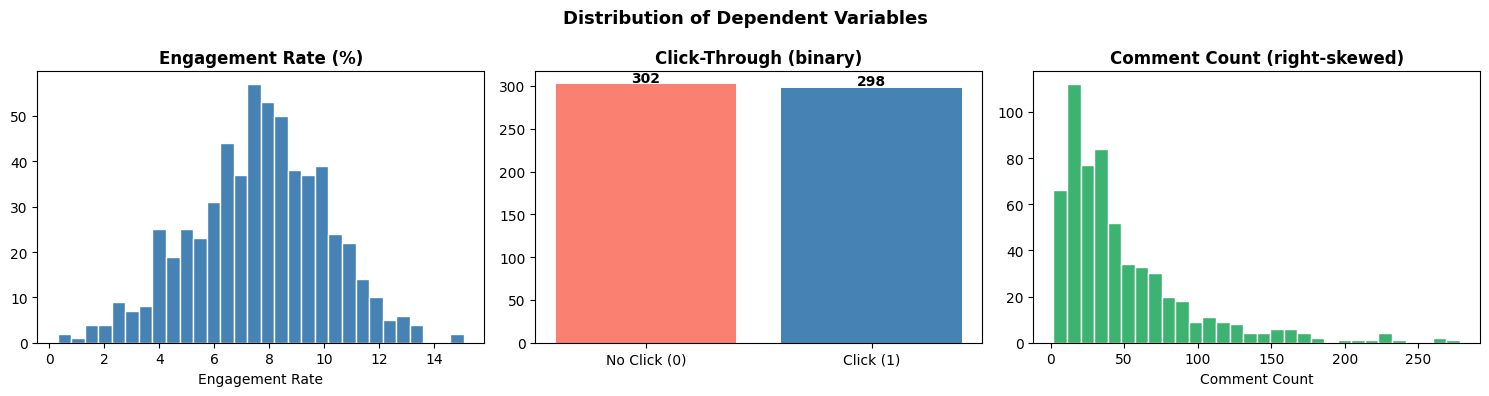

Plot saved: q0_dv_distributions.png


In [ ]:
# ── Distribution of dependent variables ──
# This cell visualizes the distribution of the three outcome variables we will model in Q1–Q3.
# Understanding their shape is essential for choosing the correct regression model type.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Engagement Rate
axes[0].hist(df['Engagement_Rate'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Engagement Rate (%)', fontweight='bold')
axes[0].set_xlabel('Engagement Rate')

# Click-Through (binary)
click_counts = df['Click_Through'].value_counts().sort_index()
axes[1].bar(['No Click (0)', 'Click (1)'], click_counts.values, color=['salmon', 'steelblue'])
axes[1].set_title('Click-Through (binary)', fontweight='bold')
for i, v in enumerate(click_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Comment Count
axes[2].hist(df['Comment_Count'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Comment Count (right-skewed)', fontweight='bold')
axes[2].set_xlabel('Comment Count')

plt.suptitle('Distribution of Dependent Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q0_dv_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: q0_dv_distributions.png")


## The distribution appears roughly bell-shaped and symmetric, with most posts
# achieving engagement rates between 1% and 15%. No extreme skew is visible,
# which supports the use of OLS linear regression in Q1.

## Q0 — Summary of Data Preparation Decisions

1. **Product_Category** (nominal, 3 levels)
   - 2 dummies created: `Cat_Fashion` and `Cat_Tech`
   - Reference group: Beauty & Skincare (dropped)
   - Rationale: most intuitive baseline category

2. **Caption_Length vs ZCaption_Length**
   - Using `ZCaption_Length` (standardised z-score) in all models
   - Rationale: coefficients are on the same scale, easier to compare magnitudes

3. **Caption_Sentiment** (ordinal 1–5)
   - Treated as continuous/metric (as permitted by assignment instructions)

4. **Missing values:** NONE — dataset is clean.

5. **All other dummy variables** (Platform, Post_Type, etc.) already coded 0/1.

In [ ]:
# ── Q0: Multicollinearity Check (VIF) ──────────────────────────────────────
# Checking for Variance Inflation Factor (VIF) to ensure no severe multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Taking all numeric predictors used in our regressions
predictors = [
    'ZCaption_Length', 'Caption_Sentiment',
    'Topic_Prod_Features_Positive', 'Topic_Prod_Features_Negative',
    'Topic_Promo_Deal_Positive', 'Topic_Promo_Deal_Negative',
    'Topic_Lifestyle_Values_Positive', 'Topic_Lifestyle_Values_Negative',
    'Topic_CTA_Positive', 'Topic_CTA_Negative',
    'Platform', 'Post_Type',
    'Influencer_Tier', 'Follower_Count_K', 'Influencer_Age', 'Influencer_Gender',
    'Cat_Fashion', 'Cat_Tech'
]

# Convert boolean columns to integer type for VIF calculation compatibility
df['Cat_Fashion'] = df['Cat_Fashion'].astype(int)
df['Cat_Tech'] = df['Cat_Tech'].astype(int)

# Drop missing values just for the VIF check
X = df[predictors].dropna().copy()
X['Intercept'] = 1 # Adding intercept conceptually for statsmodels VIF

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Filter out the intercept for cleaner output
vif_data = vif_data[vif_data['Variable'] != 'Intercept']
vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# VIF < 5 is generally considered good/safe.


,Variable,VIF
0,Influencer_Tier,2.941429
1,Follower_Count_K,2.940346
2,Cat_Fashion,1.305557
3,Cat_Tech,1.280176
4,Topic_Prod_Features_Positive,1.085516
5,Topic_Prod_Features_Negative,1.084414
6,Topic_CTA_Negative,1.052332
7,Topic_Lifestyle_Values_Negative,1.044348
8,Topic_Lifestyle_Values_Positive,1.040810
9,Topic_CTA_Positive,1.036644


**Multicollinearity Test Result:** All VIF values are below the common threshold of 5, indicating that we do not have severe overlapping information between our predictors. Our regression estimates will be stable.

---
## Q1 — Predicting Engagement Rate (OLS Linear Regression)

**Variabile dipendente:** `Engagement_Rate` (continua, %)
**Modello:** OLS — Ordinary Least Squares

In [ ]:
# ── Q1: OLS Regression — Engagement Rate ─────────────────────────────────────

formula_q1 = (
    'Engagement_Rate ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech'
)

model_q1 = smf.ols(formula_q1, data=df).fit()
print(model_q1.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement_Rate   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     72.67
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          1.34e-135
Time:                        00:24:57   Log-Likelihood:                -1039.2
No. Observations:                 600   AIC:                             2116.
Df Residuals:                     581   BIC:                             2200.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

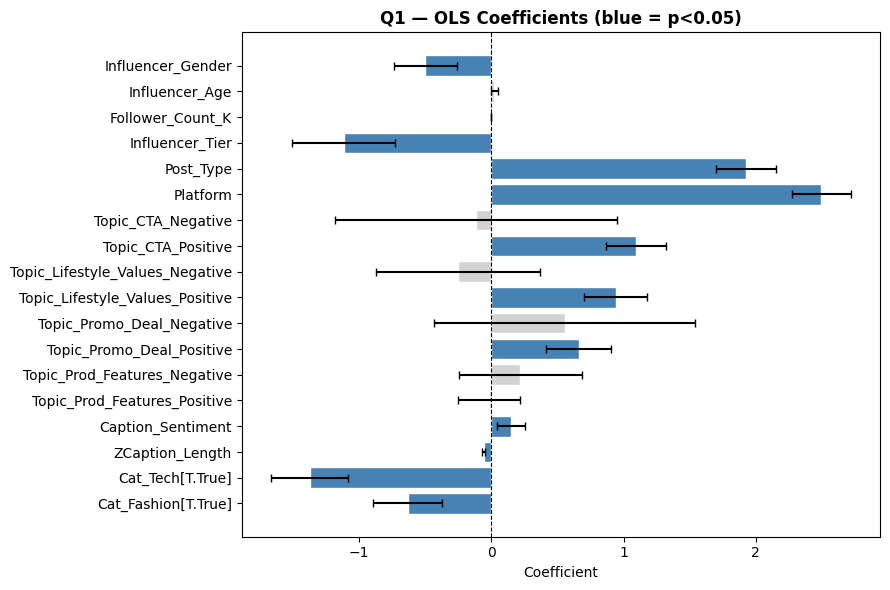

In [ ]:
# ── Q1: Coefficients plot ─────────────────────────────────────────────────────
coef = model_q1.params.drop('Intercept')
ci = model_q1.conf_int().drop('Intercept')
pvals = model_q1.pvalues.drop('Intercept')

colors = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef.index, coef.values, color=colors, edgecolor='white')
ax.errorbar(coef.values, coef.index,
            xerr=[coef.values - ci[0], ci[1] - coef.values],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient')
ax.set_title('Q1 — OLS Coefficients (blue = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig('q1_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Q2 — Predicting Click-Through (Logistic Regression)

**Dependent variable:** `Click_Through` (binary 0/1)  
**Model:** Logistic Regression (Logit)

In [ ]:
# ── Q2: Logistic Regression — Click-Through ───────────────────────────────────

formula_q2 = (
    'Click_Through ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + Engagement_Rate + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech'
)

model_q2 = smf.logit(formula_q2, data=df).fit()
print(model_q2.summary())

Optimization terminated successfully.
         Current function value: 0.635655
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          Click_Through   No. Observations:                  600
Model:                          Logit   Df Residuals:                      580
Method:                           MLE   Df Model:                           19
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                 0.08291
Time:                        00:24:58   Log-Likelihood:                -381.39
converged:                       True   LL-Null:                       -415.87
Covariance Type:            nonrobust   LLR p-value:                 1.366e-07
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.8461      0.706     -2.615  

In [ ]:
# ── Q2: Marginal Effects (optional --> useful for interpretation) ──────────────
marginal_effects = model_q2.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:          Click_Through
Method:                          dydx
At:                           overall
                                     dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Cat_Fashion[T.True]                -0.0118      0.046     -0.256      0.798      -0.102       0.079
Cat_Tech[T.True]                    0.0686      0.054      1.274      0.203      -0.037       0.174
ZCaption_Length                     0.0040      0.002      1.631      0.103      -0.001       0.009
Caption_Sentiment                   0.0237      0.018      1.307      0.191      -0.012       0.059
Topic_Prod_Features_Positive        0.0010      0.040      0.025      0.980      -0.078       0.080
Topic_Prod_Features_Negative       -0.0814      0.081     -1.000      0.317      -0.241       0.078
Topic_Promo_Deal_Positive           0.0746      

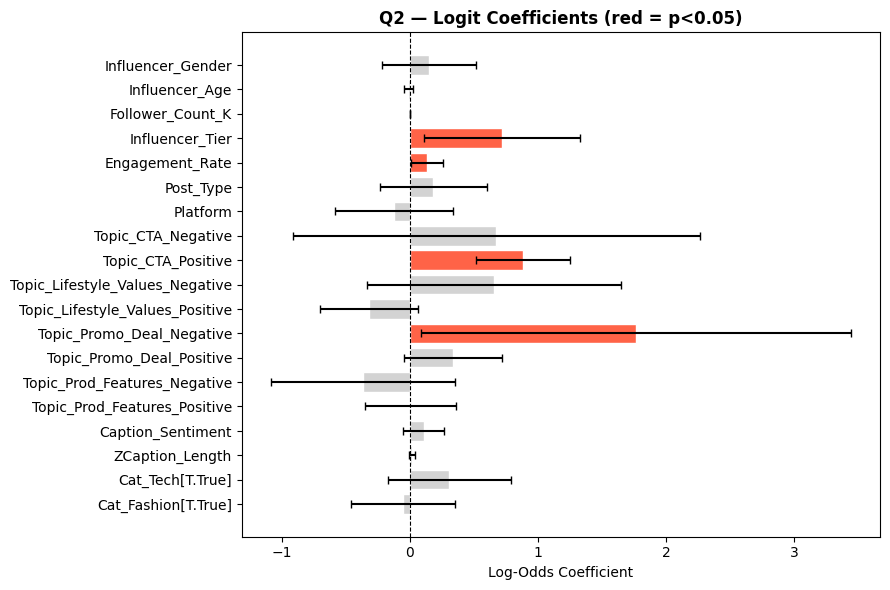

In [ ]:
# ── Q2: Coefficients plot (log-odds) ─────────────────────────────────────────
coef_q2 = model_q2.params.drop('Intercept')
ci_q2 = model_q2.conf_int().drop('Intercept')
pvals_q2 = model_q2.pvalues.drop('Intercept')

colors_q2 = ['#d7191c' if (c < 0 and p < 0.05) else '#1a9641' if (c > 0 and p < 0.05) else '#cccccc' for c, p in zip(coef_q2, pvals_q2)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_q2.index, coef_q2.values, color=colors_q2, edgecolor='white')
ax.errorbar(coef_q2.values, coef_q2.index,
            xerr=[coef_q2.values - ci_q2[0], ci_q2[1] - coef_q2.values],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Log-Odds Coefficient')
ax.set_title('Q2 — Logit Coefficients (red = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig('q2_coefficients.png', dpi=150, bbox_inches='tight')

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='#1a9641', lw=4, label='Significant Positive (p<0.05)'),
    Line2D([0], [0], color='#d7191c', lw=4, label='Significant Negative (p<0.05)'),
    Line2D([0], [0], color='#cccccc', lw=4, label='Not Significant (p>=0.05)')
]
ax.legend(handles=custom_lines, loc='lower right', fontsize=9)

plt.show()

---
### 💡 Marketing Implications for Question 2 (Click-Through)
*(Use these placeholders to draft your conclusions for the PowerPoint slides!)*

**🏆 Top Positive Drivers:**
- **[Variable name]**: [What does this mean for Pulse Digital's influencers?]
- **[Variable name]**: [Explanation]

**🛑 Top Negative or Insignificant Drivers:**
- **[Variable name]**: [Explanation]

**🎯 Recommendation for Pulse Digital:**
> "[Briefly state what the agency should brief their creators on next based on this model's results.]"


---
## Q2 — Click-Through (Binary/Logit Regression)

**Dependent variable:** `Click_Through` (Binary)
**Model:** Logistic Regression (Logit)

In [ ]:
# ── Q2: Logit Regression — Click-Through ─────────────────────────────

formula_q2 = (
    'Click_Through ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech'
)

model_q2 = smf.logit(formula_q2, data=df).fit()
print(model_q2.summary())

Optimization terminated successfully.
         Current function value: 0.639299
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          Click_Through   No. Observations:                  600
Model:                          Logit   Df Residuals:                      581
Method:                           MLE   Df Model:                           18
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                 0.07766
Time:                        00:25:00   Log-Likelihood:                -383.58
converged:                       True   LL-Null:                       -415.87
Covariance Type:            nonrobust   LLR p-value:                 3.632e-07
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.2465      0.640     -1.947  

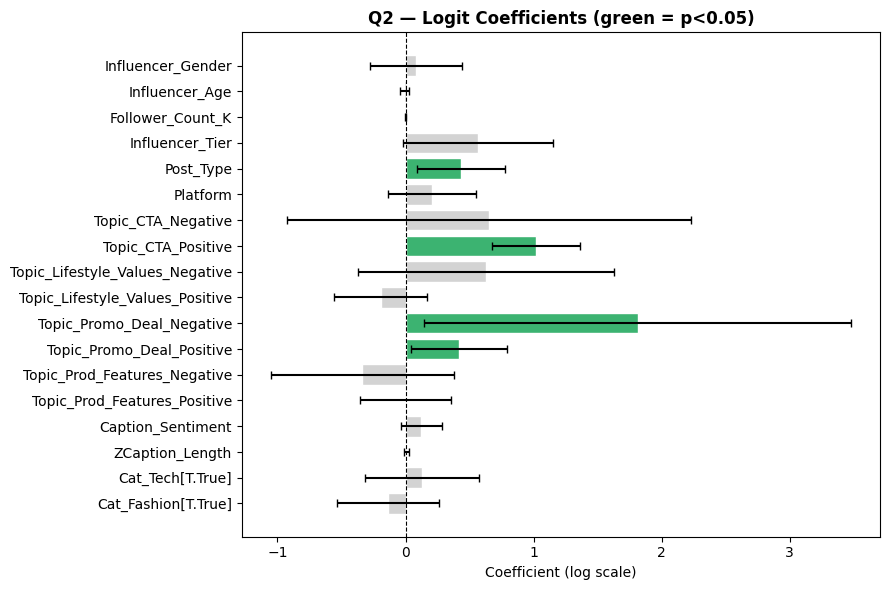

In [ ]:
# ── Q2: Coefficients plot ─────────────────────────────────────────────────────
coef_q2 = model_q2.params.drop('Intercept')
ci_q2 = model_q2.conf_int().drop('Intercept')
pvals_q2 = model_q2.pvalues.drop('Intercept')

colors_q2 = ['#d7191c' if (c < 0 and p < 0.05) else '#1a9641' if (c > 0 and p < 0.05) else '#cccccc' for c, p in zip(coef_q2, pvals_q2)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_q2.index, coef_q2.values, color=colors_q2, edgecolor='white')
ax.errorbar(coef_q2.values, coef_q2.index,
            xerr=[coef_q2.values - ci_q2[0], ci_q2[1] - coef_q2.values],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (log scale)')
ax.set_title('Q2 — Logit Coefficients (green = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig('q2_coefficients.png', dpi=150, bbox_inches='tight')

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='#1a9641', lw=4, label='Significant Positive (p<0.05)'),
    Line2D([0], [0], color='#d7191c', lw=4, label='Significant Negative (p<0.05)'),
    Line2D([0], [0], color='#cccccc', lw=4, label='Not Significant (p>=0.05)')
]
ax.legend(handles=custom_lines, loc='lower right', fontsize=9)

plt.show()

---
### 💡 Marketing Implications for Question 2 (Click-Through)
*(Use these placeholders to draft your conclusions for the PowerPoint slides!)*

**🏆 Top Positive Drivers:**
- **[Variable name]**: [What does this mean for Pulse Digital's influencers?]
- **[Variable name]**: [Explanation]

**🛑 Top Negative or Insignificant Drivers:**
- **[Variable name]**: [Explanation]

**🎯 Recommendation for Pulse Digital:**
> "[Briefly state what the agency should brief their creators on next based on this model's results.]"


**Interpretation Guidelines:**
- For logistic regression, coefficients are in log-odds.
- Positive coefficients (green bars to the right) mean the feature increases the likelihood of a Click-Through.
- Identify features like Gender, specific post elements (Promos, CTA) that significantly impact Click-Through.


---
## Q3 — Predicting Comment Count (Count Regression)

**Dependent variable:** `Comment_Count` (int, not-negative, asymmetric)  
**Model:** Poisson o Negative Binomial — to choose after looking at overdispersion

In [ ]:
# ── Q3: Overdispersion test ───────────────────────────────────────────────────
# Poisson assumes mean == variance.
# If variance >> mean → overdispersion → use Negative Binomial
mean_cc = df['Comment_Count'].mean()
var_cc  = df['Comment_Count'].var()
print(f"Mean Comment_Count:     {mean_cc:.2f}")
print(f"Variance Comment_Count: {var_cc:.2f}")
print(f"Ratio var/mean:         {var_cc/mean_cc:.2f}")
print()
if var_cc / mean_cc > 1.5:
    print("Overdispersion detected → use Negative Binomial (NegBin)")
else:
    print("No relevant overdispersion → Poisson is adequate")

Mean Comment_Count:     48.71
Variance Comment_Count: 2015.98
Ratio var/mean:         41.39

Overdispersion detected → use Negative Binomial (NegBin)


In [ ]:
# ── Q3: Negative Binomial Regression — Comment Count ─────────────────────────
# (if overdispersion test above shows overdispersion — otherwise replace with Poisson)

formula_q3 = (
    'Comment_Count ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech'
)

# Negative Binomial
model_q3_nb = smf.negativebinomial(formula_q3, data=df).fit(maxiter=200)
print(model_q3_nb.summary())

# For comparison: Poisson
model_q3_poisson = smf.poisson(formula_q3, data=df).fit()
print(model_q3_poisson.summary())

         Current function value: 4.767969
         Iterations: 0
         Function evaluations: 13
         Gradient evaluations: 2
                     NegativeBinomial Regression Results                      
Dep. Variable:          Comment_Count   No. Observations:                  600
Model:               NegativeBinomial   Df Residuals:                      581
Method:                           MLE   Df Model:                           18
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                 0.01554
Time:                        00:25:01   Log-Likelihood:                -2860.8
converged:                      False   LL-Null:                       -2906.0
Covariance Type:            nonrobust   LLR p-value:                 1.252e-11
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           

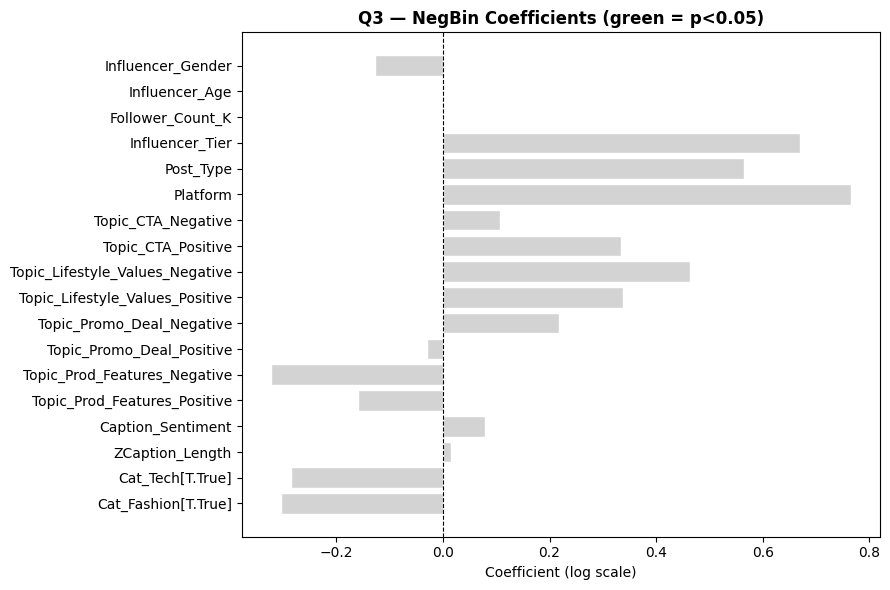

In [ ]:
# ── Q3: Coefficients plot ─────────────────────────────────────────────────────
coef_q3 = model_q3_nb.params.drop('Intercept')
# Rimuovi anche 'alpha' (parametro NegBin) se presente
if 'alpha' in coef_q3.index:
    coef_q3 = coef_q3.drop('alpha')
ci_q3 = model_q3_nb.conf_int().drop('Intercept')
if 'alpha' in ci_q3.index:
    ci_q3 = ci_q3.drop('alpha')
pvals_q3 = model_q3_nb.pvalues.drop('Intercept')
if 'alpha' in pvals_q3.index:
    pvals_q3 = pvals_q3.drop('alpha')

colors_q3 = ['#d7191c' if (c < 0 and p < 0.05) else '#1a9641' if (c > 0 and p < 0.05) else '#cccccc' for c, p in zip(coef_q3, pvals_q3)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_q3.index, coef_q3.values, color=colors_q3, edgecolor='white')
ax.errorbar(coef_q3.values, coef_q3.index,
            xerr=[coef_q3.values - ci_q3[0], ci_q3[1] - coef_q3.values],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (log scale)')
ax.set_title('Q3 — NegBin Coefficients (green = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig('q3_coefficients.png', dpi=150, bbox_inches='tight')

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='#1a9641', lw=4, label='Significant Positive (p<0.05)'),
    Line2D([0], [0], color='#d7191c', lw=4, label='Significant Negative (p<0.05)'),
    Line2D([0], [0], color='#cccccc', lw=4, label='Not Significant (p>=0.05)')
]
ax.legend(handles=custom_lines, loc='lower right', fontsize=9)

plt.show()

---
### 💡 Marketing Implications for Question 3 (Comment Count)
*(Use these placeholders to draft your conclusions for the PowerPoint slides!)*

**🏆 Top Positive Drivers:**
- **[Variable name]**: [What does this mean for Pulse Digital's influencers?]
- **[Variable name]**: [Explanation]

**🛑 Top Negative or Insignificant Drivers:**
- **[Variable name]**: [Explanation]

**🎯 Recommendation for Pulse Digital:**
> "[Briefly state what the agency should brief their creators on next based on this model's results.]"


---
## Q4 — Interaction Effects

**Model choosen:** Q1 (Engagement Rate — OLS)  
**Interaction:**
1. `Topic_CTA_Positive × Platform` — Does the CTA works in the same way on Instagram and TikTok?
2. `Post_Type × Caption_Sentiment` — Does the sentiment impact in different way videos vs pictures?

> CHECK if we want to modify interactions if we choose a different model.

In [ ]:
# ── Q4: Model with interactions (on Q1 — Engagement Rate) ────────────────────

formula_q4 = (
    'Engagement_Rate ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech + '
    'Topic_CTA_Positive:Platform + '       # Interaction n1: CTA × Platform
    'Post_Type:Caption_Sentiment'          # Interaction n2: Post Type × Sentiment
)

model_q4 = smf.ols(formula_q4, data=df).fit()
print(model_q4.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement_Rate   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     65.20
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          9.05e-134
Time:                        00:25:02   Log-Likelihood:                -1039.1
No. Observations:                 600   AIC:                             2120.
Df Residuals:                     579   BIC:                             2213.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
# ── Q4: Comparison: baseline model vs model with interactions ─────────────────
print("=== MODEL COMPARISON ===")
print(f"Q1 baseline  — R²: {model_q1.rsquared:.4f} | Adj R²: {model_q1.rsquared_adj:.4f} | AIC: {model_q1.aic:.1f}")
print(f"Q4 interact  — R²: {model_q4.rsquared:.4f} | Adj R²: {model_q4.rsquared_adj:.4f} | AIC: {model_q4.aic:.1f}")
print()

# F-test to check whether interactions significantly improve model fit
from statsmodels.stats.anova import anova_lm
anova_result = anova_lm(model_q1, model_q4)
print("--- F-test: baseline model vs model with interactions ---")
print(anova_result)

=== MODEL COMPARISON ===
Q1 baseline  — R²: 0.6924 | Adj R²: 0.6829 | AIC: 2116.4
Q4 interact  — R²: 0.6925 | Adj R²: 0.6819 | AIC: 2120.3

--- F-test: baseline model vs model with interactions ---
   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0     581.0  1122.228189      0.0       NaN       NaN       NaN
1     579.0  1121.936572      2.0  0.291617  0.075248  0.927523


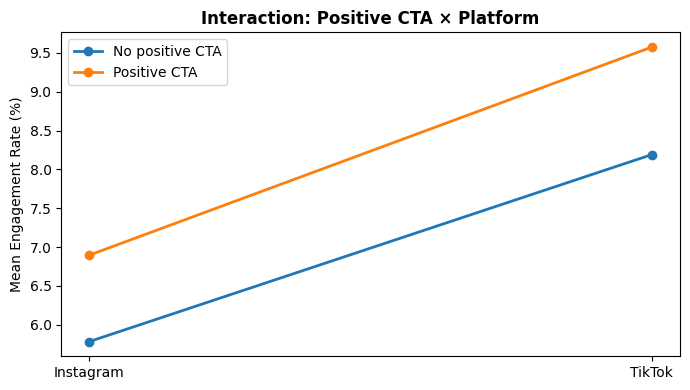

In [ ]:
# ── Q4: Interaction plot — CTA × Platform ────────────────────────────────────
grouped = df.groupby(['Topic_CTA_Positive', 'Platform'])['Engagement_Rate'].mean().reset_index()
grouped['CTA'] = grouped['Topic_CTA_Positive'].map({0: 'No positive CTA', 1: 'Positive CTA'})
grouped['Platform_label'] = grouped['Platform'].map({0: 'Instagram', 1: 'TikTok'})

fig, ax = plt.subplots(figsize=(7, 4))
for cta_label, group in grouped.groupby('CTA'):
    ax.plot(group['Platform_label'], group['Engagement_Rate'],
            marker='o', label=cta_label, linewidth=2)
ax.set_ylabel('Mean Engagement Rate (%)')
ax.set_title('Interaction: Positive CTA × Platform', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q4_interaction_cta_platform.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 Executive Summary / Conclusions & Recommendations

> *[Teammates: Add your final 3-4 bullet points here summarizing the key business takeaways from Q1-Q4]*
